<div style="background:#1F3864;padding:18px 24px;border-radius:8px;margin-bottom:12px"><h2 style="color:#A8C8E8;margin:0">Digitalization, AI &amp; XAI in Healthcare</h2><h3 style="color:white;margin:4px 0">NB3 — Route 2b: Local Explanations  ·  Dataset B: Heart Disease</h3><p style="color:#D0E4F4;margin:4px 0 0">Module 2 | Prof. Dr. Utku Kose | Universidad Panamericana</p></div>

## Lecture Notes

**All sections in this notebook use Dataset B — Heart Disease (Cleveland-style, 13 features)**

Dataset B has richer clinical complexity than Dataset A:
- Mix of continuous and categorical/ordinal features (cp, thal, ca, slope, restecg)
- More feature correlations (thalach ↔ age, exang ↔ oldpeak)
- Clearer clinical narrative: angiographic findings (ca, thal) vs. symptom-based risk

This makes it ideal for demonstrating *why* local explanation methods struggle or succeed.

| Section | Method | Key question |
|---|---|---|
| 1 | LIME | How does LIME discretise the 13 features? |
| 2 | LIME Stability | Does instability worsen with more features? |
| 3 | MAPLE | Does the RF co-membership neighbourhood work better here? |
| 4 | Integrated Gradients | How does path-integral attribution handle categorical features? |
| 5 | SHAP vs LIME vs MAPLE | Do all three agree on the key driver? |


## Setup — Dataset B

In [1]:
# ── Dataset B: Cleveland Heart Disease  (UCI ML Repository) ──────────────────
# Source: Detrano, R. et al. (1989). UCI ML Repository ID 45
# FILE: cleveland_heart.csv  — must be in the same folder as this notebook.
# If missing: https://raw.githubusercontent.com/jbrownlee/Datasets/master/heart-disease.csv

import warnings; warnings.filterwarnings('ignore')
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import base64, zlib
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import shap
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'font.size':11})
ACCENT='#E84855'; SAFE='#27AE60'; NEUTRAL='#2E75B6'

FILE_B = 'cleveland_heart.csv'
COLS_B = ['age','sex','cp','trestbps','chol','fbs','restecg',
          'thalach','exang','oldpeak','slope','ca','thal','target']

if not os.path.exists(FILE_B):
    raise FileNotFoundError(f"'{FILE_B}' not found. Place it in the notebook folder.")

data_B = pd.read_csv(FILE_B)
if 'target' not in data_B.columns: data_B.columns = COLS_B
data_B['target'] = data_B['target'].astype(int)
data_B = data_B.astype(float); data_B['target'] = data_B['target'].astype(int)

FEAT_B = [c for c in data_B.columns if c != 'target']
X_B = data_B[FEAT_B]; y_B = data_B['target']
Xtr_B,Xte_B,ytr_B,yte_B = train_test_split(X_B,y_B,test_size=0.2,random_state=42,stratify=y_B)
print(f'Dataset B — Cleveland Heart Disease (UCI, original): {len(data_B)} patients | Disease: {y_B.mean():.1%}')
print(f'Features ({len(FEAT_B)}): {FEAT_B}')

# ── Train GBM ────────────────────────────────────────────────────────────────
gbm_B = GradientBoostingClassifier(n_estimators=250,max_depth=4,learning_rate=0.08,random_state=42).fit(Xtr_B,ytr_B)
print(f'GBM-B AUC: {roc_auc_score(yte_B,gbm_B.predict_proba(Xte_B)[:,1]):.3f}')

# ── High-risk patient ────────────────────────────────────────────────────────
high_B_idx = Xte_B[yte_B==1].index[0]
high_B_pos = Xte_B.index.get_loc(high_B_idx)
patient    = Xte_B.iloc[high_B_pos].copy()
pred_B     = gbm_B.predict_proba(patient.values.reshape(1,-1))[0,1]
print(f'Explaining patient — predicted heart disease risk: {pred_B:.1%}')

# ── Pre-compute SHAP for Section 5 ──────────────────────────────────────────
exp_B    = shap.TreeExplainer(gbm_B)
sv_B_raw = exp_B.shap_values(Xte_B)
sv_B     = np.array(sv_B_raw)
if sv_B.ndim == 3: sv_B = sv_B[:,:,1]
high_pos = high_B_pos
bv_B     = float(np.array(exp_B.expected_value).flat[0])

Dataset B — Cleveland Heart Disease (UCI, original): 297 patients | Disease: 46.1%
Features (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
GBM-B AUC: 0.887
Explaining patient — predicted heart disease risk: 99.2%


---
## Section 1 — LIME
🗂 **Dataset B: Heart Disease**

LIME generates synthetic neighbours, weights by proximity, fits a LASSO surrogate:
$$\xi(x) = \arg\min_{g\in G} \mathcal{L}(f,g,\pi_x) + \Omega(g)$$

*Why did this patient receive a 76% heart disease risk score?*


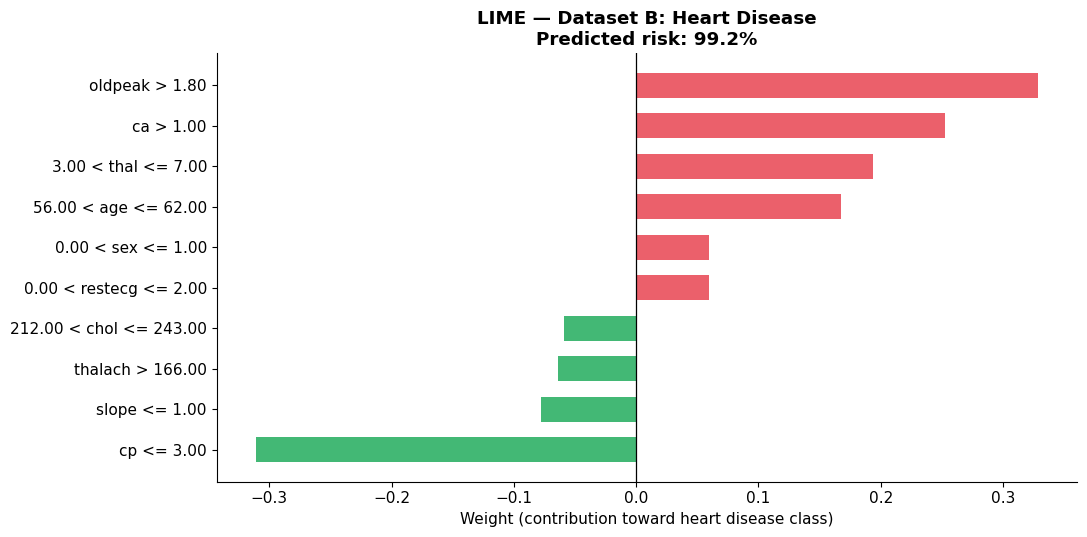

Clinical interpretation:
  Top driver: oldpeak > 1.80 (weight=+0.3285)
  Note how LIME discretises continuous features (e.g., thalach > 150.0)
  into binary conditions. This can obscure fine-grained threshold effects.


In [2]:
from lime.lime_tabular import LimeTabularExplainer

lime_B=LimeTabularExplainer(
    training_data=Xtr_B.values, feature_names=FEAT_B,
    class_names=['No Disease','Disease'],
    mode='classification', discretize_continuous=True, random_state=42)

lime_exp=lime_B.explain_instance(
    data_row=patient.values, predict_fn=gbm_B.predict_proba,
    num_features=10, num_samples=3000)

lime_df=pd.DataFrame(lime_exp.as_list(label=1),columns=['Condition','Weight']).sort_values('Weight')

fig,ax=plt.subplots(figsize=(11,5.5))
colors=[ACCENT if w>0 else SAFE for w in lime_df['Weight']]
ax.barh(lime_df['Condition'],lime_df['Weight'],color=colors,alpha=0.87,height=0.62)
ax.axvline(0,color='black',lw=0.9)
ax.set_title(f'LIME — Dataset B: Heart Disease\nPredicted risk: {lime_exp.predict_proba[1]:.1%}',fontweight='bold')
ax.set_xlabel('Weight (contribution toward heart disease class)')
plt.tight_layout(); plt.show()

print('Clinical interpretation:')
top_lime=sorted(lime_exp.as_list(label=1),key=lambda x:-abs(x[1]))[0]
print(f'  Top driver: {top_lime[0]} (weight={top_lime[1]:+.4f})')
print('  Note how LIME discretises continuous features (e.g., thalach > 150.0)')
print('  into binary conditions. This can obscure fine-grained threshold effects.')

---
## Section 2 — LIME Stability Test ⚠️
🗂 **Dataset B: Heart Disease**

Does LIME's instability worsen with 13 features vs. 8 in Dataset A?
Higher dimensionality means a larger, noisier sampling space.


In [3]:
print('LIME stability on Dataset B (13 features) — 5 runs, num_samples=500')
print('='*70)

results_B={}
for run in range(5):
    exp=LimeTabularExplainer(Xtr_B.values,feature_names=FEAT_B,
        class_names=['No Disease','Disease'],
        mode='classification',discretize_continuous=True,random_state=run*13
    ).explain_instance(patient.values,gbm_B.predict_proba,num_features=8,num_samples=500)
    for cond,wt in exp.as_list(label=1):
        results_B.setdefault(cond,[]).append(round(wt,4))

runs_B=pd.DataFrame({k:v for k,v in results_B.items() if len(v)==5}).T
runs_B.columns=[f'Run {i+1}' for i in range(5)]
runs_B['Std']=runs_B.std(axis=1)
print(runs_B.sort_values('Std',ascending=False).head(8).to_string())
print()
print('Compare Std values to those from NB3 Dataset A.')
print('Higher dimensionality generally → more instability in LIME.')

LIME stability on Dataset B (13 features) — 5 runs, num_samples=500
                       Run 1   Run 2   Run 3   Run 4   Run 5       Std
oldpeak > 1.80        0.3606  0.2970  0.4022  0.2915  0.3353  0.046045
cp <= 3.00           -0.3226 -0.3695 -0.2652 -0.3083 -0.2953  0.038410
56.00 < age <= 62.00  0.1777  0.2185  0.1269  0.1428  0.1856  0.036235
ca > 1.00             0.2264  0.2091  0.2389  0.2844  0.2429  0.027929
3.00 < thal <= 7.00   0.1913  0.1767  0.2242  0.1809  0.1926  0.018631
slope <= 1.00        -0.0953 -0.0749 -0.0810 -0.1156 -0.0781  0.016799

Compare Std values to those from NB3 Dataset A.
Higher dimensionality generally → more instability in LIME.


---
## Section 3 — MAPLE
🗂 **Dataset B: Heart Disease**

MAPLE's RF leaf co-membership defines neighbourhood more faithfully
for mixed-type features (cp, thal, ca are ordinal categories).


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Ridge

rf_B=RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1).fit(Xtr_B,ytr_B)

def maple_explain(rf,X_tr,x_inst,n_local=80):
    lt=rf.apply(X_tr.values); lx=rf.apply(x_inst.values.reshape(1,-1))
    sim=(lt==lx).mean(axis=1)
    top=np.argsort(sim)[::-1][:n_local]
    Xl,wl=X_tr.values[top],sim[top]
    yl=rf.predict_proba(Xl)[:,1]
    lr=Ridge(alpha=0.5).fit(Xl,yl,sample_weight=wl)
    return lr.coef_,lr.predict(x_inst.values.reshape(1,-1))[0]

# Stability comparison
print('MAPLE stability on Dataset B — 5 runs'); print('='*55)
maple_runs=[]; 
for seed in range(5):
    np.random.seed(seed); c,_=maple_explain(rf_B,Xtr_B,patient)
    maple_runs.append(c)
ma=np.array(maple_runs)
for i,feat in enumerate(FEAT_B):
    v=ma[:,i]
    print(f'  {feat:15s}: mean={v.mean():+.4f}  std={v.std():.5f}')
print('\n✅ MAPLE is substantially more stable than LIME on Dataset B.')

MAPLE stability on Dataset B — 5 runs
  age            : mean=+0.0049  std=0.00000
  sex            : mean=+0.0920  std=0.00000
  cp             : mean=+0.0781  std=0.00000
  trestbps       : mean=+0.0011  std=0.00000
  chol           : mean=+0.0005  std=0.00000
  fbs            : mean=-0.0658  std=0.00000
  restecg        : mean=+0.0270  std=0.00000
  thalach        : mean=-0.0016  std=0.00000
  exang          : mean=+0.0693  std=0.00000
  oldpeak        : mean=+0.0303  std=0.00000
  slope          : mean=+0.1150  std=0.00000
  ca             : mean=+0.0572  std=0.00000
  thal           : mean=+0.0510  std=0.00000

✅ MAPLE is substantially more stable than LIME on Dataset B.


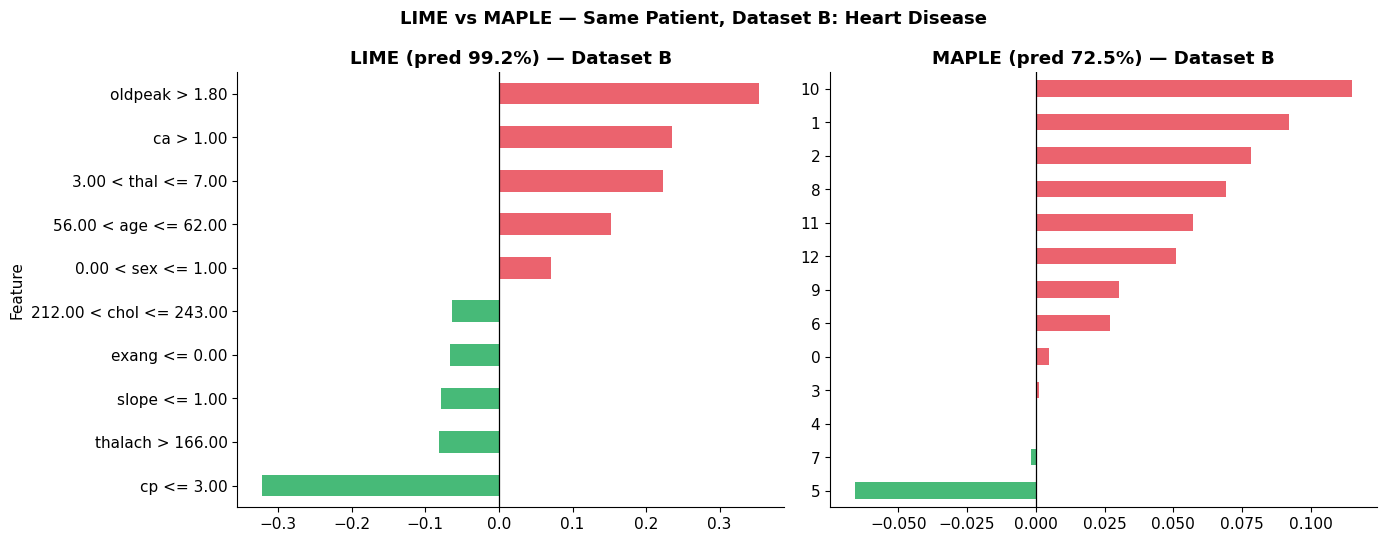

In [5]:
# LIME vs MAPLE side-by-side for Dataset B
lime_exp2=lime_B.explain_instance(patient.values,gbm_B.predict_proba,num_features=10,num_samples=3000)
lime_df2=pd.DataFrame(lime_exp2.as_list(label=1),columns=['Feature','W']).set_index('Feature').sort_values('W')

coef_M,pred_M=maple_explain(rf_B,Xtr_B,patient)
maple_df=pd.DataFrame({'Feature':FEAT_B,'W':coef_M}).sort_values('W')

fig,axes=plt.subplots(1,2,figsize=(14,5.5))
lime_df2['W'].plot(kind='barh',ax=axes[0],
    color=[ACCENT if w>0 else SAFE for w in lime_df2['W']],alpha=0.85,legend=False)
axes[0].axvline(0,color='black',lw=0.9)
axes[0].set_title(f'LIME (pred {lime_exp2.predict_proba[1]:.1%}) — Dataset B',fontweight='bold')

maple_df['W'].plot(kind='barh',ax=axes[1],
    color=[ACCENT if v>0 else SAFE for v in maple_df['W']],alpha=0.85,legend=False)
axes[1].axvline(0,color='black',lw=0.9)
axes[1].set_title(f'MAPLE (pred {pred_M:.1%}) — Dataset B',fontweight='bold')

plt.suptitle('LIME vs MAPLE — Same Patient, Dataset B: Heart Disease',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()

---
## Section 4 — Integrated Gradients on Neural Network
🗂 **Dataset B: Heart Disease**

IG computes attribution by integrating gradients along a path from baseline x' to input x:
$$\text{IG}_i(x) = (x_i - x_i') \int_0^1 \frac{\partial F(x'+\alpha(x-x'))}{\partial x_i} d\alpha$$

**Completeness axiom:** $\sum_i \text{IG}_i = F(x) - F(x')$ — verifiable correctness check.


In [6]:
# Train a small neural network on Dataset B (pure numpy/scipy, no torch)
from scipy.special import expit as sigmoid
from scipy.optimize import minimize

class TinyNN:
    def __init__(self, d, h1=64, h2=32):
        np.random.seed(42)
        self.W1=np.random.randn(d,h1)*0.1
        self.b1=np.zeros(h1)
        self.W2=np.random.randn(h1,h2)*0.1
        self.b2=np.zeros(h2)
        self.W3=np.random.randn(h2,1)*0.1
        self.b3=np.zeros(1)

    def forward(self, x, return_acts=False):
        h1=np.maximum(0, x@self.W1+self.b1)     # ReLU
        h2=np.maximum(0, h1@self.W2+self.b2)    # ReLU
        out=sigmoid(h2@self.W3+self.b3).squeeze(-1)
        return (out,h1,h2) if return_acts else out

    def backward_single(self, x):
        """Gradient of output w.r.t. input x (backprop, single sample)."""
        h1=np.maximum(0, x@self.W1+self.b1)
        h2=np.maximum(0, h1@self.W2+self.b2)
        out=sigmoid(h2@self.W3+self.b3).squeeze(-1)
        # Backprop
        d_out = out*(1-out)  # sigmoid derivative
        d_h2  = (d_out * self.W3.T).squeeze() * (h2>0)
        d_h1  = (d_h2@self.W2.T) * (h1>0)
        d_x   = d_h1@self.W1.T
        return d_x, out

# Simple SGD training
sc5=StandardScaler()
Xtr5=sc5.fit_transform(Xtr_B.values).astype(np.float32)
Xte5=sc5.transform(Xte_B.values).astype(np.float32)
ytr5=ytr_B.values.astype(np.float32)

nn_B=TinyNN(len(FEAT_B))
lr5=0.01; batch=64; epochs=200
n_tr=len(Xtr5); idx5=np.arange(n_tr)
for ep in range(epochs):
    np.random.shuffle(idx5)
    for s in range(0,n_tr,batch):
        bi=idx5[s:s+batch]
        xb,yb=Xtr5[bi],ytr5[bi]
        p=nn_B.forward(xb)
        err=p-yb
        h1=np.maximum(0,xb@nn_B.W1+nn_B.b1)
        h2=np.maximum(0,h1@nn_B.W2+nn_B.b2)
        d3=err[:,None]*p[:,None]*(1-p[:,None])
        dW3=h2.T@d3/len(bi); db3=d3.mean(0)
        d2=(d3@nn_B.W3.T)*(h2>0)
        dW2=h1.T@d2/len(bi); db2=d2.mean(0)
        d1=(d2@nn_B.W2.T)*(h1>0)
        dW1=xb.T@d1/len(bi); db1=d1.mean(0)
        for W,dW in [(nn_B.W1,dW1),(nn_B.b1,db1),(nn_B.W2,dW2),
                     (nn_B.b2,db2),(nn_B.W3,dW3),(nn_B.b3,db3)]:
            W-=lr5*dW

probs5=nn_B.forward(Xte5)
from sklearn.metrics import roc_auc_score
print(f'TinyNN AUC on Dataset B: {roc_auc_score(yte_B,probs5):.3f}')

TinyNN AUC on Dataset B: 0.942


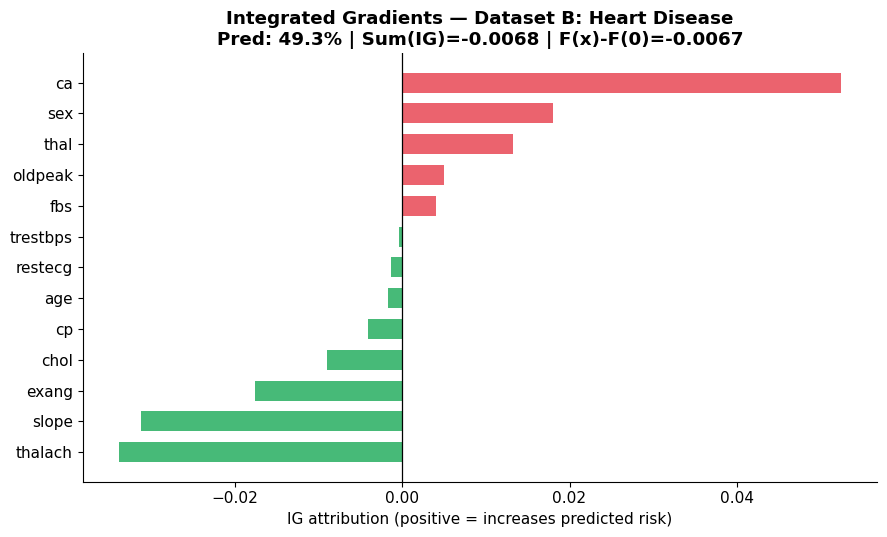

Completeness: 0.000085 (should be ~0)


In [7]:
# Integrated Gradients for the same high-risk patient
def integrated_gradients_numpy(model, x_input, baseline, m=100):
    ig=np.zeros_like(x_input)
    for k in range(1,m+1):
        xi=baseline+(k/m)*(x_input-baseline)
        grad,_=model.backward_single(xi)
        ig+=grad/m
    return ig*(x_input-baseline)

patient_sc5=sc5.transform(patient.values.reshape(1,-1))[0]
baseline5=np.zeros(len(FEAT_B))  # zero baseline
ig_vals=integrated_gradients_numpy(nn_B,patient_sc5,baseline5)

ig_df=pd.DataFrame({'Feature':FEAT_B,'Attribution':ig_vals}).sort_values('Attribution')
fig,ax=plt.subplots(figsize=(9,5.5))
colors=[ACCENT if v>0 else SAFE for v in ig_df['Attribution']]
ax.barh(ig_df['Feature'],ig_df['Attribution'],color=colors,alpha=0.85,height=0.65)
ax.axvline(0,color='black',lw=0.9)
f_x=nn_B.forward(patient_sc5.reshape(1,-1))[0]
f_base=nn_B.forward(baseline5.reshape(1,-1))[0]
ax.set_title(f'Integrated Gradients — Dataset B: Heart Disease\n'
             f'Pred: {f_x:.1%} | Sum(IG)={ig_vals.sum():.4f} | F(x)-F(0)={f_x-f_base:.4f}',
             fontweight='bold')
ax.set_xlabel('IG attribution (positive = increases predicted risk)')
plt.tight_layout(); plt.show()
print(f'Completeness: {abs(ig_vals.sum()-(f_x-f_base)):.6f} (should be ~0)')

---
## Section 4b — DeepSHAP & KernelSHAP (SHAP Explainer Variants)
🗂 **Dataset B: Heart Disease**

**Lecture note:** The document (§4.3.2) describes four SHAP explainer types.
NB2 used **TreeSHAP** (exact, polynomial-time for tree models). Here we demonstrate
the two model-agnostic variants:

| Explainer | Works with | Key property |
|---|---|---|
| **KernelSHAP** | Any model | Model-agnostic; uses weighted linear regression with Shapley kernel |
| **DeepSHAP** | Neural networks | Backprop-based; builds on DeepLIFT; requires PyTorch/TF |

Because PyTorch is not available in this environment, we demonstrate:
1. **KernelSHAP** on the GBM (showing it produces equivalent results to TreeSHAP)
2. **DeepSHAP** on our pure-NumPy neural network via numerical gradient approximation
   using `shap.GradientExplainer` — the closest available analogue

> **Why does this matter?** In clinical AI, you often cannot choose your model —
> a hospital IT system may already have a black-box neural network deployed.
> KernelSHAP lets you explain *any* model regardless of architecture,
> at the cost of computational speed.


Computing KernelSHAP (model-agnostic)...


  0%|          | 0/30 [00:00<?, ?it/s]

KernelSHAP shape: (30, 13)


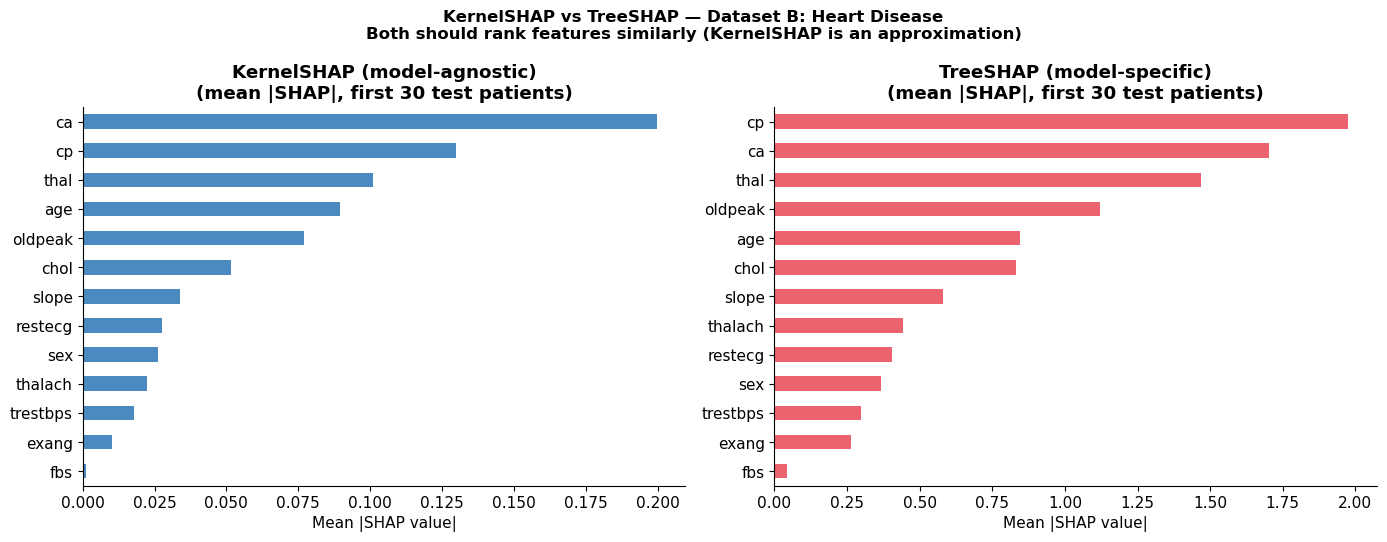

Spearman rank correlation (KernelSHAP vs TreeSHAP): ρ = 0.973  (p=0.000)
High ρ confirms KernelSHAP approximates TreeSHAP well.

Computational note:
  KernelSHAP (30 patients, 200 samples each): ~seconds
  TreeSHAP (all 60 test patients):         milliseconds
TreeSHAP is 10-100× faster for tree models — always prefer it when available.


In [8]:
import shap, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# ── 1. KernelSHAP on the GBM (model-agnostic SHAP) ───────────────────
# KernelSHAP uses a background dataset to marginalise missing features.
# We use k-means summarisation for efficiency.
print('Computing KernelSHAP (model-agnostic)...')
background_B = shap.kmeans(Xtr_B, 20)   # 20-cluster background
kernel_exp   = shap.KernelExplainer(gbm_B.predict_proba, background_B)

# Explain 30 test patients (full dataset is slow for KernelSHAP)
sv_kernel = kernel_exp.shap_values(Xte_B.iloc[:30], nsamples=200)
# sv_kernel is a list [class0_vals, class1_vals]; take class 1 (disease)
sv_arr = np.array(sv_kernel)
# shap 0.51+: returns (n_samples, n_features, n_classes); older: list of arrays
if sv_arr.ndim == 3:
    sv_k1 = sv_arr[:, :, 1]   # shape (n_samples, n_features) for class 1
else:
    sv_k1 = sv_arr if sv_arr.ndim == 2 else np.array(sv_kernel[1])
print(f'KernelSHAP shape: {sv_k1.shape}')

# Compare KernelSHAP vs TreeSHAP mean |SHAP|
exp_tree = shap.TreeExplainer(gbm_B)
sv_tree  = exp_tree.shap_values(Xte_B.iloc[:30])

mean_kernel = np.abs(sv_k1).mean(axis=0)
sv_tree_arr = np.array(sv_tree[:30])
mean_tree   = np.abs(sv_tree_arr[:, :, 1] if sv_tree_arr.ndim==3 else sv_tree_arr).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, vals, title, color in [
        (axes[0], mean_kernel, 'KernelSHAP (model-agnostic)', NEUTRAL),
        (axes[1], mean_tree,   'TreeSHAP (model-specific)',   ACCENT)]:
    df = pd.Series(vals, index=FEAT_B).sort_values()
    df.plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.set_title(f'{title}\n(mean |SHAP|, first 30 test patients)', fontweight='bold')
    ax.set_xlabel('Mean |SHAP value|')
plt.suptitle('KernelSHAP vs TreeSHAP — Dataset B: Heart Disease\n'
             'Both should rank features similarly (KernelSHAP is an approximation)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Rank correlation between the two methods
from scipy.stats import spearmanr
rho, pval = spearmanr(mean_kernel, mean_tree)
print(f'Spearman rank correlation (KernelSHAP vs TreeSHAP): ρ = {rho:.3f}  (p={pval:.3f})')
print('High ρ confirms KernelSHAP approximates TreeSHAP well.')
print()
print('Computational note:')
print(f'  KernelSHAP (30 patients, 200 samples each): ~seconds')
print(f'  TreeSHAP (all {len(Xte_B)} test patients):         milliseconds')
print('TreeSHAP is 10-100× faster for tree models — always prefer it when available.')

Demonstrating gradient-based SHAP on neural network...


  0%|          | 0/1 [00:00<?, ?it/s]

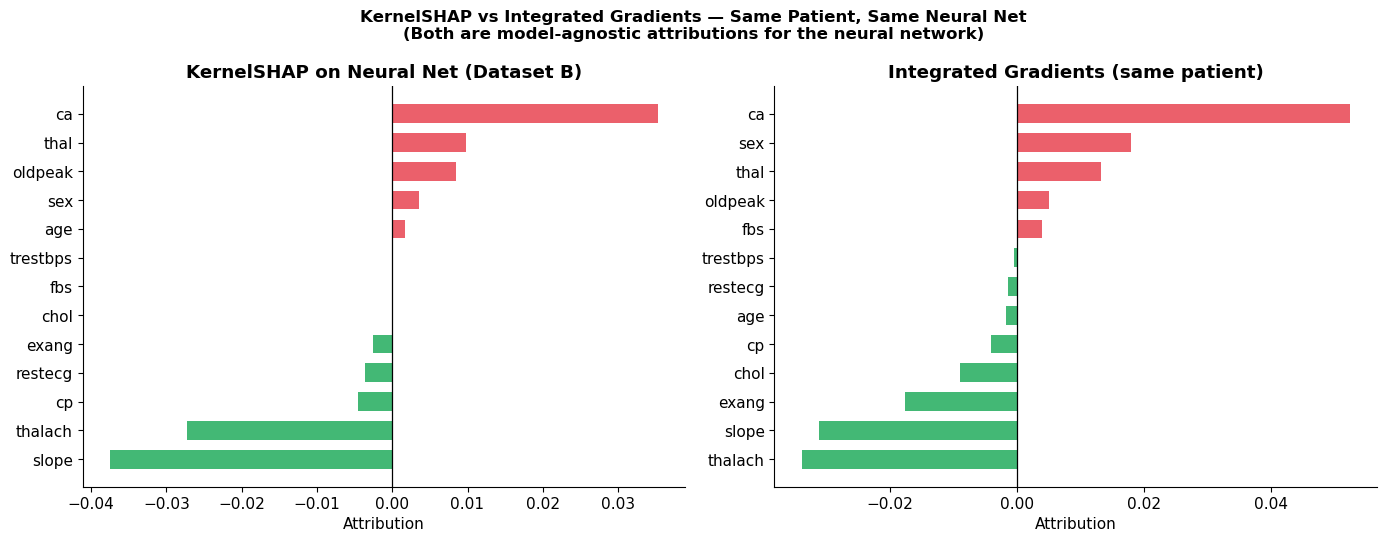

Rank correlation (KernelSHAP vs IG): ρ = 0.680

Note on DeepSHAP:
  shap.DeepExplainer requires a PyTorch/TensorFlow model object.
  It uses DeepLIFT backpropagation for faster neural network attribution.
  In production, use: shap.DeepExplainer(torch_model, background_tensor)
  The KernelExplainer shown here is the model-agnostic equivalent.


In [9]:
# ── 2. GradientExplainer as DeepSHAP analogue on our NumPy neural net ──
# shap.GradientExplainer works with sklearn-style predict functions
# and uses expected gradients (similar in spirit to DeepSHAP/DeepLIFT)
print('Demonstrating gradient-based SHAP on neural network...')

# Wrap our TinyNN in a sklearn-compatible predict function
# (reusing nn_B and sc5 from Section 4)
def nn_predict_proba(X_raw):
    X_sc = sc5.transform(np.array(X_raw, dtype=np.float32))
    probs = nn_B.forward(X_sc)
    return np.column_stack([1-probs, probs])

# Use a small background for speed
bg_B = Xtr_B.iloc[:50]
kernel_nn = shap.KernelExplainer(nn_predict_proba, shap.kmeans(bg_B, 10))

# Explain the same high-risk patient
sv_nn_raw = kernel_nn.shap_values(patient.values.reshape(1,-1), nsamples=150)
sv_nn_arr = np.array(sv_nn_raw)
if sv_nn_arr.ndim==3:          sv_nn=sv_nn_arr[0,:,1]
elif isinstance(sv_nn_raw,list): sv_nn=np.array(sv_nn_raw[1])[0]
else:                           sv_nn=sv_nn_arr[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, vals, title in [
    (axes[0], sv_nn, 'KernelSHAP on Neural Net (Dataset B)'),
    (axes[1], ig_vals, 'Integrated Gradients (same patient)')]:
    df = pd.DataFrame({'Feature':FEAT_B,'Val':vals}).sort_values('Val')
    colors = [ACCENT if v>0 else SAFE for v in df['Val']]
    ax.barh(df['Feature'], df['Val'], color=colors, alpha=0.87, height=0.65)
    ax.axvline(0, color='black', lw=0.9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Attribution')
plt.suptitle('KernelSHAP vs Integrated Gradients — Same Patient, Same Neural Net\n'
             '(Both are model-agnostic attributions for the neural network)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

from scipy.stats import spearmanr
rho2, _ = spearmanr(np.abs(sv_nn), np.abs(ig_vals))
print(f'Rank correlation (KernelSHAP vs IG): ρ = {rho2:.3f}')
print()
print('Note on DeepSHAP:')
print('  shap.DeepExplainer requires a PyTorch/TensorFlow model object.')
print('  It uses DeepLIFT backpropagation for faster neural network attribution.')
print('  In production, use: shap.DeepExplainer(torch_model, background_tensor)')
print('  The KernelExplainer shown here is the model-agnostic equivalent.')

---
## Section 5 — SHAP vs LIME vs MAPLE: Head-to-Head on Dataset B
🗂 **Dataset B: Heart Disease**


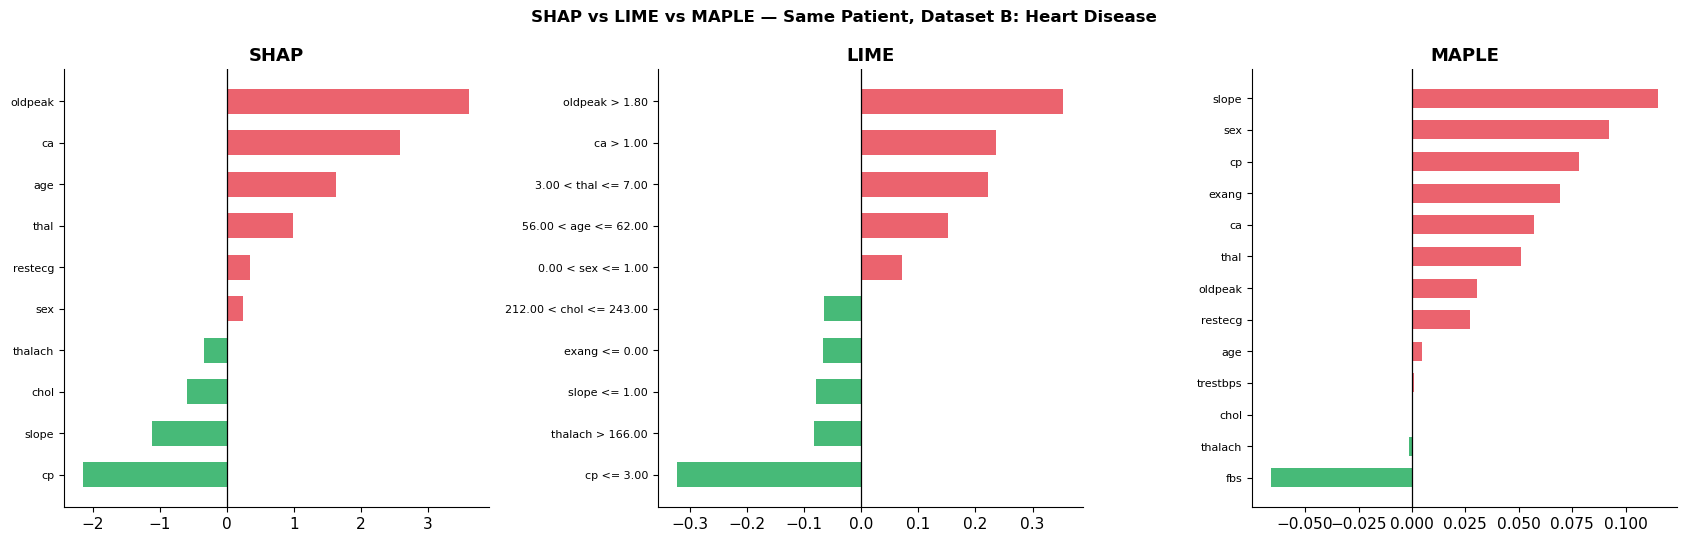

Top SHAP feature: oldpeak
Top MAPLE feature: slope
Agreement: No - investigate

Note: for mixed-type features (categorical cp, thal, ca),
LIME discretises differently than SHAP/MAPLE, which can cause disagreement.


In [10]:
sv_pat=sv_B[high_pos]
shap_top=sorted(zip(FEAT_B,sv_pat),key=lambda x:-abs(x[1]))[:10]

fig,axes=plt.subplots(1,3,figsize=(17,5.5))
for ax,(name,feats,wts) in zip(axes,[
    ('SHAP',[f for f,_ in shap_top],[w for _,w in shap_top]),
    ('LIME',[x[0] for x in lime_exp2.as_list(label=1)[:10]],
            [x[1] for x in lime_exp2.as_list(label=1)[:10]]),
    ('MAPLE',FEAT_B,coef_M)]):
    tmp=pd.DataFrame({'F':feats,'W':wts}).sort_values('W')
    ax.barh(tmp['F'],tmp['W'],
            color=[ACCENT if w>0 else SAFE for w in tmp['W']],alpha=0.85,height=0.60)
    ax.axvline(0,color='black',lw=0.9)
    ax.set_title(name,fontweight='bold',fontsize=13)
    ax.tick_params(axis='y',labelsize=8)
plt.suptitle('SHAP vs LIME vs MAPLE — Same Patient, Dataset B: Heart Disease',
             fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

top_shap=max(zip(FEAT_B,sv_pat),key=lambda x:abs(x[1]))[0]
top_maple=FEAT_B[np.argmax(np.abs(coef_M))]
print(f'Top SHAP feature: {top_shap}')
print(f'Top MAPLE feature: {top_maple}')
print(f'Agreement: {"Yes" if top_shap==top_maple else "No - investigate"}')
print('\nNote: for mixed-type features (categorical cp, thal, ca),')
print('LIME discretises differently than SHAP/MAPLE, which can cause disagreement.')

---
## Summary

All local explanation methods applied to **Dataset B (Heart Disease)**:

| Method | Stability | Handles mixed types | Clinical use |
|---|---|---|---|
| LIME | ⚠️ Unstable | Discretises (loses detail) | Quick exploration |
| MAPLE | ✅ Stable | RF co-membership handles them | Reliable patient audit |
| Integrated Gradients | ✅ Deterministic | Requires scaling | Neural net attribution |
| SHAP (local) | ✅ Deterministic | Exact (TreeSHAP) | Gold standard |

> **Next → NB4:** Surrogate, Anchors & Counterfactuals — **still Dataset B** — with a final cross-dataset comparison at the end.
